# Imports and Device Setup

In [ ]:
# 1. Imports and Device Setup
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import numpy as np

# Setup device-agnostic code (defaults to CUDA if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


# Data Generation and Visualization

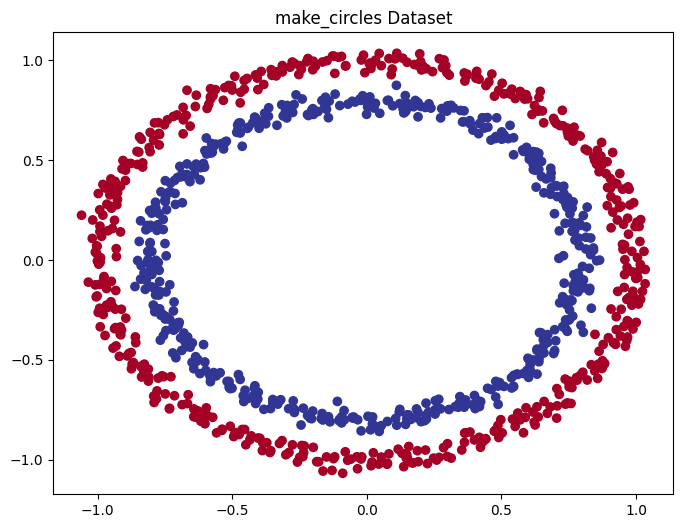

In [ ]:
# 2. Generate and visualize the make_circles dataset
# We use 1000 samples and add some noise for realism
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)

# Visualize the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.title("make_circles Dataset")
plt.show()

# Data Pre-processing

In [ ]:
# 3. Convert data to PyTorch Tensors and split
# Convert to float32 tensors
X_tensor = torch.from_numpy(X).type(torch.float)
y_tensor = torch.from_numpy(y).type(torch.float)

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

# Move data to the target device (GPU)
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

# Defining the Reusable Metric Plotter

In [ ]:
# 4. Reusable Metric Plotter Function
def plot_metrics(history_dict):
    """
    Plots training and testing metrics.
    Expects a dict: {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    """
    epochs = range(1, len(history_dict['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_dict['train_loss'], label='Train Loss')
    plt.plot(epochs, history_dict['test_loss'], label='Test Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_dict['train_acc'], label='Train Accuracy')
    plt.plot(epochs, history_dict['test_acc'], label='Test Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.legend()

    plt.show()

# Helper function to calculate accuracy
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100

# Building the neural Network

In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: torch.Size([800, 2])
y_train shape: torch.Size([800])
X_test shape: torch.Size([200, 2])
y_test shape: torch.Size([200])


In [ ]:
# 5. Build the Model
# We need non-linear activations (ReLU) to solve circular (non-linear) data
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # Non-linearity

    def forward(self, x):
        # Forward pass through layers and activations
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

# Instantiate and move to device
model_0 = CircleModel().to(device)

# Setup Loss (BCEWithLogitsLoss combines Sigmoid + Binary Cross Entropy) and Optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_0.parameters(), lr=0.1)

# The Training Loop

In [ ]:
# 6. Training Loop
epochs = 1500 # I switched this after the session to show that by increasing the number of epochs(training cycles),
# the model is given more time to train but if you notice below in the output of this cell, the model generalizes too much which raises supsicion of 
# overfitting which is terrible for validation🤓

# Dictionary to store metrics for our plotter
history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(epochs):
    ### Training
    model_0.train()

    # 1. Forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> probabilities -> labels

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Store metrics every 100 epochs
    if epoch % 100 == 0:
        history['train_loss'].append(loss.item())
        history['test_loss'].append(test_loss.item())
        history['train_acc'].append(acc)
        history['test_acc'].append(test_acc)
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.70538, Acc: 50.00% | Test Loss: 0.70678, Test Acc: 50.00%
Epoch: 100 | Loss: 0.68781, Acc: 51.38% | Test Loss: 0.68998, Test Acc: 49.00%
Epoch: 200 | Loss: 0.68461, Acc: 52.62% | Test Loss: 0.68781, Test Acc: 50.50%
Epoch: 300 | Loss: 0.68002, Acc: 57.12% | Test Loss: 0.68515, Test Acc: 53.50%
Epoch: 400 | Loss: 0.67330, Acc: 59.62% | Test Loss: 0.68131, Test Acc: 56.00%
Epoch: 500 | Loss: 0.66226, Acc: 60.50% | Test Loss: 0.67436, Test Acc: 54.50%
Epoch: 600 | Loss: 0.64394, Acc: 65.00% | Test Loss: 0.66014, Test Acc: 61.00%
Epoch: 700 | Loss: 0.60860, Acc: 78.38% | Test Loss: 0.62965, Test Acc: 71.00%
Epoch: 800 | Loss: 0.53580, Acc: 93.38% | Test Loss: 0.56391, Test Acc: 90.50%
Epoch: 900 | Loss: 0.41448, Acc: 98.75% | Test Loss: 0.45201, Test Acc: 97.50%
Epoch: 1000 | Loss: 0.26561, Acc: 99.75% | Test Loss: 0.30795, Test Acc: 99.50%
Epoch: 1100 | Loss: 0.15382, Acc: 99.75% | Test Loss: 0.19482, Test Acc: 100.00%
Epoch: 1200 | Loss: 0.09352, Acc: 100.00% | Test Lo

# Visualizing Metrics|

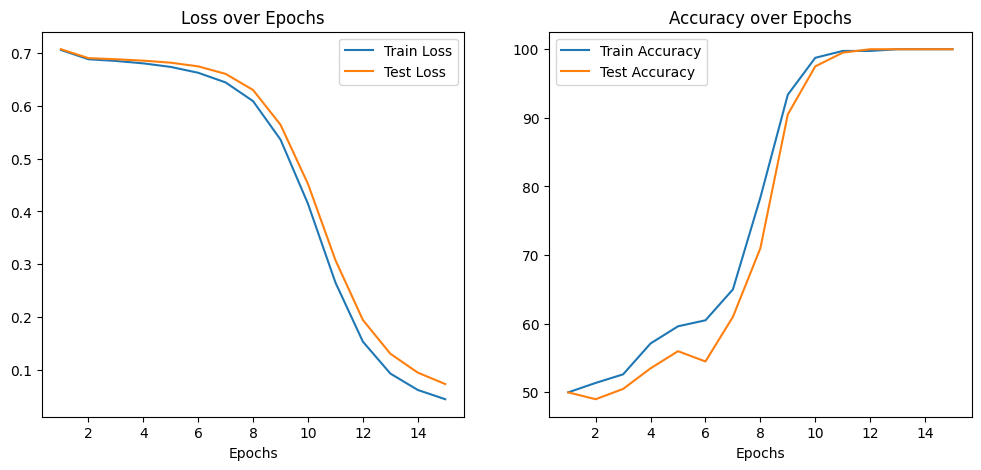

In [ ]:
# 7. Plot Performance Metrics
# Pass our saved history into the reusable function
plot_metrics(history)

# Visualizing the Decision Boundary|

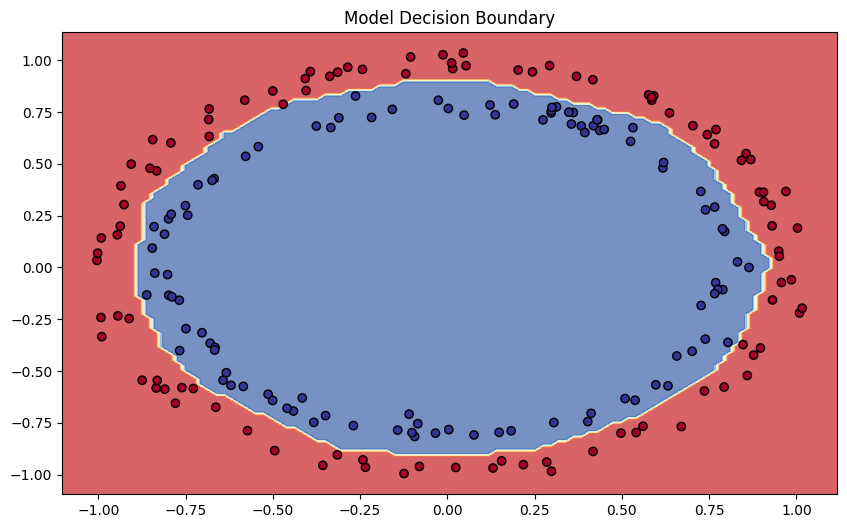

In [ ]:
# 8. Decision Boundary Plotter
def plot_decision_boundary(model, X, y):
    """Plots the decision boundary created by a model predicting on X."""
    # Move data to CPU for matplotlib
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Create a meshgrid to plot in
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make predictions across the meshgrid
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    y_pred = torch.round(torch.sigmoid(y_logits)).reshape(xx.shape).detach().numpy()

    # Plot
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k')
    plt.title("Model Decision Boundary")
    plt.show()

# Visualize how well the model separates the classes
plot_decision_boundary(model_0, X_test, y_test)